# Transduction re-analysis (offline)

Re-process **already-saved** Wigner sweep data (no hardware) to compute the
decoder entanglement fidelity F_e(eta) and coherent information I_c(eta), and to
A/B the two channel-phase de-rotation methods:

- **Method A** -- raw reconstructed rho + a *single* logical-Z de-rotation by
  phi_ch read from |+_L> (phases only |2>; leaves the |1><3| odd coherence at the
  raw channel phase).
- **Method B** -- per-state rotate='optimal' to the ideal *channel output*
  (full-Fock rotation exp(-i theta N); phases the even AND odd coherences by the
  same factor, so the K1 odd-branch recovery works). This is the multiphoton
  recipe.

Files are located via the **job-server DB** by `user` (so other people's
interleaved Wigner jobs are excluded), then read from the per-job
`*_WignerTomography1ModeExperiment.h5` (`alpha`, `parity`, `sigma_z_discard_frac`)
and run through `WignerAnalysis` with `config=None`. No hardware; the DB is only
queried read-only to map job_id -> data file.

In [3]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from fitting.wigner import WignerAnalysis
from experiments.transduction.channel_model import (
    logical_ket, ideal_channel_output, channel_output, process_operators,
    offdiag_from_states, entanglement_fidelity, coherent_information,
    apply_logical_z, even_survival,
)


Importing all classes from  C:\python\multimode_expts\experiments\dual_rail
Importing all classes from  C:\python\multimode_expts\experiments\qsim
Importing all classes from  C:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  C:\python\multimode_expts\experiments\single_qubit
Importing all classes from  C:\python\multimode_expts\experiments\transduction
Skipped top-level files ['branch_manager.py', 'characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']


## 1. Select the sweep from the job database (by user)

Files are chosen from the **job-server DB** by `user` + WignerTomography class +
COMPLETED, ordered by `job_id` -- so other people's interleaved Wigner jobs are
excluded (globbing the shared data dir would mix them in, and the per-day
`NNNNN` counter resets so it isn't even monotonic across days).

Your sweep is the contiguous block of YOUR Wigner jobs between `SWEEP_JOB_START`
and `SWEEP_JOB_END` (inclusive). Run `list_user_wigner()` (next cell) to print
your recent Wigner jobs with their dominant Fock level; the sweep is the
repeating block `[|0>->Fock0, |1>->Fock2, |+>, |+i>] x N_eta` -- read its
first/last `job_id` into START/END. Also set `USER`, `ETA_SWEEP`, `PROC_INPUTS`
(submission order), `WIG_CUTOFF`, `MEASURE_PARITY`.

In [ ]:
from job_server.database import get_database
from job_server.models import Job, JobStatus

USER        = 'seb'
ETA_SWEEP   = [round(0.05 * k, 2) for k in range(1, 20)]   # 0.05 .. 0.95 (EDIT to match)
PROC_INPUTS = ['0', '1', '+', '+i']                        # submission order within each eta
WIG_CUTOFF  = 4
DIM         = WIG_CUTOFF
MEASURE_PARITY = False        # Rung 1 sweep -> False ; Rung 2 -> True

# The sweep = a contiguous block of USER's COMPLETED Wigner jobs (submission order),
# selected by job_id range [START, END] inclusive. job_id is a string so it orders
# correctly across YYYYMMDD boundaries. Use list_user_wigner() (next cell) to find it.
SWEEP_JOB_START = 'JOB-20260604-00550'   # <- this run's pasted Fe sweep (auto-located)
SWEEP_JOB_END   = 'JOB-20260605-00135'


GRID = [(eta, L) for eta in ETA_SWEEP for L in PROC_INPUTS]
print(f'{len(ETA_SWEEP)} eta x {len(PROC_INPUTS)} inputs = {len(GRID)} Wigner runs expected')

19 eta x 4 inputs = 76 Wigner runs expected


In [5]:
import h5py

def db_wigner_jobs(user=USER):
    """All of `user`'s COMPLETED WignerTomography1Mode jobs, (job_id, data_path),
    ordered by job_id; only those whose data file still exists on disk."""
    db = get_database()
    with db.session() as s:
        out = [(j.job_id, j.data_file_path) for j in s.query(Job).filter(
            Job.user == user,
            Job.experiment_class == 'WignerTomography1ModeExperiment',
            Job.status == JobStatus.COMPLETED).order_by(Job.job_id).all()]
    return [(jid, p) for jid, p in out if p and os.path.exists(p)]

def load_wig(path):
    with h5py.File(path, 'r') as h:
        d = {'alpha': h['alpha'][:], 'parity': h['parity'][:]}
        if 'sigma_z_discard_frac' in h:
            d['sigma_z_discard_frac'] = float(h['sigma_z_discard_frac'][()])
    return d

_jobs = db_wigner_jobs()
sweep = [(jid, p) for jid, p in _jobs if SWEEP_JOB_START <= jid <= SWEEP_JOB_END]
assert len(sweep) == len(GRID), (
    f'selected {len(sweep)} jobs in [{SWEEP_JOB_START}, {SWEEP_JOB_END}] but expect '
    f'{len(GRID)}. Adjust the range using list_user_wigner().')
RUNS = {GRID[i]: load_wig(sweep[i][1]) for i in range(len(GRID))}
print('mapped', len(RUNS), 'jobs:', sweep[0][0], '->', sweep[-1][0])


def list_user_wigner(n=90):
    """Recent USER Wigner jobs with dominant Fock + |coh20| -- to locate a sweep
    block (the repeating [Fock0, Fock2, coherent, coherent]). Read the block's
    first/last job_id into SWEEP_JOB_START / SWEEP_JOB_END (cell above)."""
    print(f'{"job_id":>20} {"domFock":>7} {"|c20|":>6}')
    for jid, p in db_wigner_jobs()[-n:]:
        try:
            d = load_wig(p)
            wa = WignerAnalysis(d, threshold=0.0, config=None, mode_state_num=DIM,
                                alphas=d['alpha'])
            M = np.asarray(wa.wigner_analysis_results(
                d['parity'], initial_state=qt.basis(DIM, 0), rotate=False)['rho'])
            pp = np.real(np.diag(M))
            print(f'{jid:>20} {int(np.argmax(pp)):>7} {abs(M[2, 0]):6.3f}')
        except Exception as e:
            print(f'{jid:>20}   (skip: {type(e).__name__})')

# list_user_wigner(90)   # <- uncomment to find your sweep's START/END job_id

mapped 76 jobs: JOB-20260604-00550 -> JOB-20260605-00135


## 2. Sanity-check the file -> (eta, logical) mapping

Reconstruct each run RAW and print Fock populations + |coh20|. Verify by eye:
`0` -> pop0 high, `1` -> pop2 high, `+`/`+i` -> a coherence present. If the
columns look scrambled, the file ordering is wrong (fix `JOB_MIN/MAX` or
`EXPLICIT_FILES`).


In [6]:
def _raw_rho(data):
    wa = WignerAnalysis(data, threshold=0.0, config=None,
                        mode_state_num=DIM, alphas=data['alpha'])
    M = wa.wigner_analysis_results(data['parity'],
            initial_state=qt.basis(DIM, 0), rotate=False)['rho']
    return np.asarray(M.full() if hasattr(M, 'full') else M)

# --- populations for a few eta (all 4 inputs) ---
print(f'{"eta":>5} {"L":>3} {"p0":>5} {"p1":>5} {"p2":>5} {"p3":>5} {"|c20|":>6} {"ang20":>6}')
for eta in ETA_SWEEP[::max(1, len(ETA_SWEEP) // 6)]:
    for L in PROC_INPUTS:
        M = _raw_rho(RUNS[(eta, L)]); p = np.real(np.diag(M))
        print(f'{eta:5.2f} {L:>3} {p[0]:5.2f} {p[1]:5.2f} {p[2]:5.2f} {p[3]:5.2f} '
              f'{abs(M[2, 0]):6.3f} {np.degrees(np.angle(M[2, 0])):6.0f}')

# --- AUTO-VALIDATE the mapping at the 3 highest eta (cleanest regime) ---
# At high eta: input |0> -> Fock 0 dominant, input |1> (=Fock 2) -> Fock 2 dominant.
print('\nMapping check (top 3 eta):')
ok = True
for eta in sorted(ETA_SWEEP)[-3:]:
    a0 = int(np.argmax(np.real(np.diag(_raw_rho(RUNS[(eta, '0')])))))
    a1 = int(np.argmax(np.real(np.diag(_raw_rho(RUNS[(eta, '1')])))))
    good = (a0 == 0 and a1 == 2); ok = ok and good
    print(f'  eta={eta:.2f}: argmax(|0>)={a0} (want 0)  argmax(|1>)={a1} (want 2)  '
          f'{"OK" if good else "<-- MISMATCH"}')
print('MAPPING LOOKS GOOD -> proceed.' if ok else
      'MAPPING IS WRONG -> fix SWEEP_JOB_START/END (cell 3) using list_user_wigner(), then re-run from cell 3.')

  eta   L    p0    p1    p2    p3  |c20|  ang20
 0.05   0  0.17  0.80  0.02  0.01  0.003   -138
 0.05   1  0.23  0.54  0.20  0.03  0.005   -122
 0.05   +  0.20  0.66  0.12  0.02  0.025    -41
 0.05  +i  0.21  0.65  0.11  0.03  0.017      8
 0.20   0  0.25  0.71  0.04  0.00  0.023      7
 0.20   1  0.37  0.14  0.36  0.12  0.019     78
 0.20   +  0.36  0.38  0.21  0.06  0.104    -71
 0.20  +i  0.33  0.41  0.21  0.05  0.101     16
 0.35   0  0.38  0.54  0.06  0.03  0.011    -89
 0.35   1  0.41  0.07  0.29  0.22  0.004   -132
 0.35   +  0.40  0.29  0.17  0.14  0.086    -86
 0.35  +i  0.38  0.29  0.17  0.15  0.111      1
 0.50   0  0.44  0.44  0.06  0.05  0.017     54
 0.50   1  0.34  0.14  0.16  0.36  0.027     62
 0.50   +  0.43  0.26  0.12  0.19  0.050    -88
 0.50  +i  0.40  0.25  0.14  0.21  0.087     -7
 0.65   0  0.52  0.31  0.10  0.07  0.023     -2
 0.65   1  0.26  0.29  0.13  0.32  0.006   -158
 0.65   +  0.38  0.28  0.14  0.20  0.013     75
 0.65  +i  0.38  0.27  0.14  0.21  0.015

## 3. Reconstruction with a Method switch (A or B)


In [7]:
def recon_rho(data, eta, logical, method):
    wa = WignerAnalysis(data, threshold=0.0, config=None,
                        mode_state_num=DIM, alphas=data['alpha'])
    if method == 'A':
        # raw reconstruction (phase NOT removed here; de-rotated at process level)
        res = wa.wigner_analysis_results(data['parity'],
                initial_state=logical_ket(logical, DIM), rotate=False)
        return qt.Qobj(res['rho'])
    elif method == 'B':
        # per-state full-N rotation aligned to the ideal CHANNEL OUTPUT
        ideal_out = ideal_channel_output(logical_ket(logical, DIM), eta, DIM,
                        postselect='even' if MEASURE_PARITY else None)
        res = wa.wigner_analysis_results(data['parity'],
                initial_state=ideal_out, rotate='optimal')
        return qt.Qobj(res['rho_rotated'])
    raise ValueError(method)


## 4. Process-tomography metrics, per method


In [11]:
BRANCH = 'even' if MEASURE_PARITY else 'full'

def process_metrics(eta, method):
    rho = {L: recon_rho(RUNS[(eta, L)], eta, L, method) for L in PROC_INPUTS}
    if method == 'A':
        # single channel phase from |+_L>, de-rotate ALL by it (logical-Z on |2>)
        phi_ch = float(np.angle(rho['+'].full()[2, 0]))
        rho = {L: apply_logical_z(rho[L], -phi_ch) for L in PROC_INPUTS}
    else:
        phi_ch = float(np.angle(recon_rho(RUNS[(eta, '+')], eta, '+', 'A').full()[2, 0]))
    N = process_operators(rho['0'], rho['1'], rho['+'], rho['+i'])   # (N00,N20,N02,N22)
    Fe = entanglement_fidelity(*N, eta, DIM, decode=True, branch=BRANCH, physical=True)
    Ic = coherent_information(*N, eta, DIM, decode=False)
    p_even = (np.mean([1.0 - RUNS[(eta, L)].get('sigma_z_discard_frac', 0.0)
                       for L in PROC_INPUTS]) if MEASURE_PARITY else 1.0)
    return dict(Fe=Fe, Ic=Ic, phi_ch=np.degrees(phi_ch), p_even=float(p_even))

def theory_metrics(eta):
    if MEASURE_PARITY:
        rho = {L: ideal_channel_output(logical_ket(L, DIM), eta, DIM, postselect='even')
               for L in PROC_INPUTS}
        N = process_operators(rho['0'], rho['1'], rho['+'], rho['+i'])
    else:
        N00, N02, N20, N22, _, _ = channel_output(eta, DIM)
        N = (N00, N20, N02, N22)
    Fe = entanglement_fidelity(*N, eta, DIM, decode=True, branch=BRANCH, physical=True)
    Ic = coherent_information(*N, eta, DIM, decode=False)
    return Fe, Ic


## 5. Sweep both methods and compare to theory


  eta   Fe_A   Fe_B  Fe_th      Ic_A    Ic_B   Ic_th
 0.05  0.258  0.353  0.382    -0.608  -0.600  -0.530
 0.10  0.247  0.454  0.492    -0.461  -0.446  -0.356
 0.15  0.238  0.507  0.581    -0.393  -0.393  -0.187
 0.20  0.243  0.567  0.651    -0.311  -0.271  -0.032
 0.25  0.268  0.592  0.701    -0.289  -0.257  +0.098
 0.30  0.251  0.582  0.735    -0.244  -0.270  +0.189
 0.35  0.265  0.552  0.752    -0.338  -0.346  +0.211
 0.40  0.268  0.566  0.754    -0.337  -0.360  +0.160
 0.45  0.305  0.500  0.742    -0.404  -0.459  +0.084
 0.50  0.325  0.516  0.717    -0.423  -0.444  -0.000
 0.55  0.356  0.459  0.680    -0.493  -0.483  -0.084
 0.60  0.336  0.452  0.632    -0.500  -0.508  -0.160
 0.65  0.377  0.412  0.575    -0.495  -0.533  -0.211
 0.70  0.384  0.388  0.579    -0.511  -0.533  -0.189
 0.75  0.437  0.473  0.623    -0.457  -0.445  -0.098
 0.80  0.539  0.502  0.677    -0.360  -0.399  +0.032
 0.85  0.553  0.558  0.740    -0.315  -0.276  +0.187
 0.90  0.673  0.657  0.814    -0.111  -0.135  

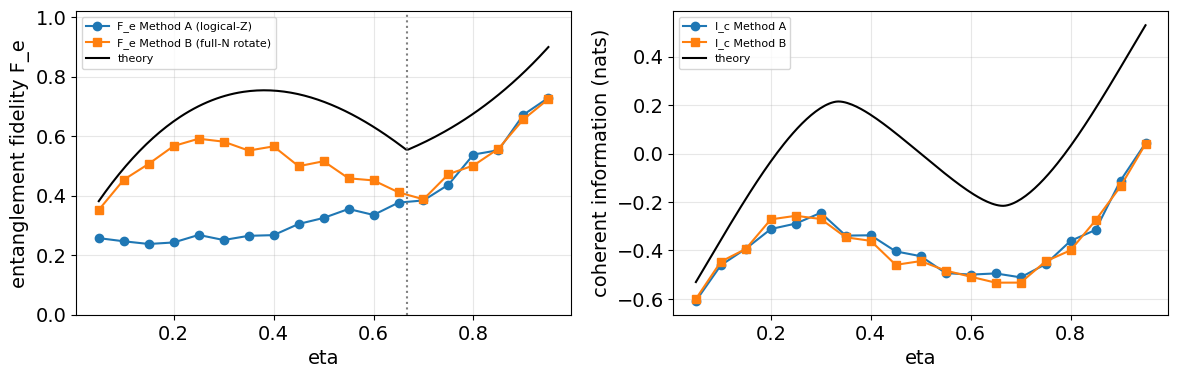

In [12]:
rows = {m: [process_metrics(eta, m) for eta in ETA_SWEEP] for m in ('A', 'B')}
eta_th = np.linspace(min(ETA_SWEEP), max(ETA_SWEEP), 200)
Fe_th, Ic_th = zip(*[theory_metrics(e) for e in eta_th])

print(f'{"eta":>5} {"Fe_A":>6} {"Fe_B":>6} {"Fe_th":>6}   {"Ic_A":>7} {"Ic_B":>7} {"Ic_th":>7}')
for i, eta in enumerate(ETA_SWEEP):
    fth, ith = theory_metrics(eta)
    print(f'{eta:5.2f} {rows["A"][i]["Fe"]:6.3f} {rows["B"][i]["Fe"]:6.3f} {fth:6.3f}   '
          f'{rows["A"][i]["Ic"]:+7.3f} {rows["B"][i]["Ic"]:+7.3f} {ith:+7.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ETA_SWEEP, [r['Fe'] for r in rows['A']], 'o-', label='F_e Method A (logical-Z)')
ax[0].plot(ETA_SWEEP, [r['Fe'] for r in rows['B']], 's-', label='F_e Method B (full-N rotate)')
ax[0].plot(eta_th, Fe_th, 'k-', label='theory')
ax[0].axvline(2 / 3, color='gray', ls=':'); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel('eta'); ax[0].set_ylabel('entanglement fidelity F_e')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].plot(ETA_SWEEP, [r['Ic'] for r in rows['A']], 'o-', label='I_c Method A')
ax[1].plot(ETA_SWEEP, [r['Ic'] for r in rows['B']], 's-', label='I_c Method B')
ax[1].plot(eta_th, Ic_th, 'k-', label='theory')
ax[1].set_xlabel('eta'); ax[1].set_ylabel('coherent information (nats)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
